# Analisis de Resultados: NN vs PGNN0 vs PGNN

Notebook para extraer resultados existentes, consolidar metricas y graficar error vs inconsistencia fisica.

In [42]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat

# Si conoces la ruta exacta del repo en este kernel, dejala aqui.
# Si no existe en este entorno, el codigo intentara auto-detectarla.
PROJECT_ROOT_OVERRIDE = Path('/home/isabel/PGNN')


def has_expected_results_structure(p: Path) -> bool:
    return (
        (p / 'results' / 'NN').exists()
        and (p / 'results' / 'PGNN0').exists()
        and (p / 'results' / 'PGNN').exists()
        and (p / 'datasets').exists()
    )


def count_result_files(p: Path) -> int:
    if not has_expected_results_structure(p):
        return 0
    total = 0
    for model in ['NN', 'SVM', 'LSBoost', 'PGNN0', 'PGNN']:
        total += len(list((p / 'results' / model).rglob('*_results.mat')))
    return total


def find_repo_by_signature() -> Path | None:
    # Busca en ubicaciones comunes sin recorrer todo el filesystem.
    search_bases = [Path.cwd(), Path('/home'), Path('/workspaces'), Path('/workspace'), Path('/content'), Path('/mnt')]
    best_path = None
    best_count = 0

    for base in search_bases:
        if not base.exists():
            continue

        # 1) Caso directo: la base ya es el repo
        c = count_result_files(base)
        if c > best_count:
            best_count = c
            best_path = base

        # 2) Busca carpetas llamadas PGNN (profundidad acotada por nombre)
        try:
            for candidate in base.rglob('PGNN'):
                if not candidate.is_dir():
                    continue
                c = count_result_files(candidate)
                if c > best_count:
                    best_count = c
                    best_path = candidate
        except Exception:
            # Algunas rutas pueden no permitir recorrido; se ignoran.
            pass

    return best_path


def find_project_root(start: Path) -> Path:
    # 1) Override manual
    if PROJECT_ROOT_OVERRIDE.exists() and has_expected_results_structure(PROJECT_ROOT_OVERRIDE):
        return PROJECT_ROOT_OVERRIDE

    # 2) Auto-deteccion hacia arriba desde cwd
    for p in [start] + list(start.parents):
        if has_expected_results_structure(p):
            return p

    # 3) Busqueda por firma de resultados
    found = find_repo_by_signature()
    if found is not None:
        return found

    # 4) Fallback final
    return start


# Rutas base de resultados
ROOT = find_project_root(Path.cwd())
RESULTS_ROOT = ROOT / 'results'
MODEL_DIRS = {
    'NN': RESULTS_ROOT / 'NN',
    'SVM': RESULTS_ROOT / 'SVM',
    'LSBoost': RESULTS_ROOT / 'LSBoost',
    # 'LSBoostOriginal': RESULTS_ROOT / 'LSBoostOriginal',
    'PGNN0': RESULTS_ROOT / 'PGNN0',
    'PGNN': RESULTS_ROOT / 'PGNN'
}

n_files_detected = sum(len(list(d.rglob('*_results.mat'))) for d in MODEL_DIRS.values() if d.exists())

print('Directorio actual del kernel:', Path.cwd())
print('Root detectado del proyecto:', ROOT)
print('Carpeta de resultados:', RESULTS_ROOT)
print('Subcarpetas detectadas:', {k: v.exists() for k, v in MODEL_DIRS.items()})
print('Cantidad de archivos *_results.mat detectados:', n_files_detected)

if n_files_detected == 0:
    print('Aviso: este kernel no esta viendo tus resultados. Verifica que el runtime tenga acceso al workspace.')

Directorio actual del kernel: /home/isabel/PGNN
Root detectado del proyecto: /home/isabel/PGNN
Carpeta de resultados: /home/isabel/PGNN/results
Subcarpetas detectadas: {'NN': True, 'SVM': True, 'LSBoost': True, 'PGNN0': True, 'PGNN': True}
Cantidad de archivos *_results.mat detectados: 306


## 1) Cargar resultados existentes de NN, SVM, LSBoost, LSBoostOriginal, PGNN0 y PGNN

Esta celda recorre los archivos `.mat` y extrae metricas por corrida.

In [43]:
def scalar_from_mat_value(v):
    if v is None:
        return np.nan
    arr = np.asarray(v)
    if arr.size == 0:
        return np.nan
    return float(arr.reshape(-1)[0])


def extract_metrics(mat_dict):
    # Error: prioriza test_rmse
    error = scalar_from_mat_value(mat_dict.get('test_rmse'))
    if np.isnan(error):
        error = scalar_from_mat_value(mat_dict.get('rmse'))

    # Inconsistencia fisica: usa el campo mas especifico disponible
    phy_incon = scalar_from_mat_value(mat_dict.get('percentage_phy_incon'))
    if np.isnan(phy_incon):
        phy_incon = scalar_from_mat_value(mat_dict.get('physical_inconsistency'))

    # Fallback por compatibilidad con resultados antiguos
    if np.isnan(phy_incon):
        phy_incon = scalar_from_mat_value(mat_dict.get('phy_consistency'))

    return error, phy_incon


rows = []
for model_name, model_dir in MODEL_DIRS.items():
    if not model_dir.exists():
        continue

    for lake_name in ['mendota', 'mille_lacs']:
        lake_dir = model_dir / lake_name
        if not lake_dir.exists():
            continue

        for mat_path in lake_dir.glob('*_results.mat'):
            try:
                data = loadmat(mat_path)
                error, physical_inconsistency = extract_metrics(data)

                rows.append({
                    'model': model_name,
                    'lake': lake_name,
                    'file': str(mat_path.relative_to(ROOT)),
                    'error': error,
                    'physical_inconsistency': physical_inconsistency
                })
            except Exception as e:
                rows.append({
                    'model': model_name,
                    'lake': lake_name,
                    'file': str(mat_path.relative_to(ROOT)),
                    'error': np.nan,
                    'physical_inconsistency': np.nan,
                    'load_error': str(e)
                })

results_df = pd.DataFrame(rows)
print('Total archivos cargados:', len(results_df))
results_df.head()

Total archivos cargados: 306


,model,lake,file,error,physical_inconsistency
0,NN,mendota,results/NN/mendota/pgnn_mendotaAdadelta_drop0p...,2.024717,0.359469
1,NN,mendota,results/NN/mendota/pgnn_mendotaAdadelta_drop0p...,1.666798,0.368605
2,NN,mendota,results/NN/mendota/pgnn_mendotaAdadelta_drop0p...,1.539151,0.295133
3,NN,mendota,results/NN/mendota/pgnn_mendotaAdadelta_drop0p...,1.800854,0.485470
4,NN,mendota,results/NN/mendota/pgnn_mendotaAdadelta_drop0p...,1.744974,0.224126


## 2) Calcular metricas y consolidar tabla comparativa

Se agregan estadisticos por modelo y por lago para inspeccion rapida.

In [44]:
required_cols = ['model', 'lake', 'file', 'error', 'physical_inconsistency']

if results_df.empty:
    print('No se cargaron resultados. Revisa rutas en la celda 1.')
    clean_df = pd.DataFrame(columns=required_cols)
else:
    clean_df = results_df.copy()
    for col in required_cols:
        if col not in clean_df.columns:
            clean_df[col] = np.nan

clean_df['error'] = pd.to_numeric(clean_df['error'], errors='coerce')
clean_df['physical_inconsistency'] = pd.to_numeric(clean_df['physical_inconsistency'], errors='coerce')

valid_df = clean_df.dropna(subset=['error', 'physical_inconsistency']).copy()

if clean_df.empty:
    summary_table = pd.DataFrame(columns=[
        'model', 'lake', 'n_runs', 'n_with_error', 'n_with_phy', 'n_runs_used_plot',
        'error_mean', 'error_std', 'phy_incon_mean', 'phy_incon_std'
    ])
else:
    # Conteos de cobertura por modelo/lago
    coverage_table = (
        clean_df
        .groupby(['model', 'lake'], as_index=False)
        .agg(
            n_runs=('file', 'count'),
            n_with_error=('error', lambda s: s.notna().sum()),
            n_with_phy=('physical_inconsistency', lambda s: s.notna().sum())
        )
    )

    # Estadisticos solo con corridas que tienen ambas metricas (las que se pueden graficar)
    if valid_df.empty:
        stats_table = pd.DataFrame(columns=['model', 'lake', 'n_runs_used_plot', 'error_mean', 'error_std', 'phy_incon_mean', 'phy_incon_std'])
    else:
        stats_table = (
            valid_df
            .groupby(['model', 'lake'], as_index=False)
            .agg(
                n_runs_used_plot=('file', 'count'),
                error_mean=('error', 'mean'),
                error_std=('error', 'std'),
                phy_incon_mean=('physical_inconsistency', 'mean'),
                phy_incon_std=('physical_inconsistency', 'std')
            )
        )

    summary_table = (
        coverage_table
        .merge(stats_table, on=['model', 'lake'], how='left')
        .sort_values(['model', 'lake'])
        .reset_index(drop=True)
    )

print('Corridas cargadas (totales):', len(clean_df))
print('Corridas validas para grafica (error + physical_inconsistency):', len(valid_df))
display(summary_table)

if not valid_df.empty:
    display(
        valid_df[['model', 'lake', 'error', 'physical_inconsistency', 'file']]
        .sort_values(['model', 'lake', 'error'])
        .reset_index(drop=True)
    )

Corridas cargadas (totales): 306
Corridas validas para grafica (error + physical_inconsistency): 304


,model,lake,n_runs,n_with_error,n_with_phy,n_runs_used_plot,error_mean,error_std,phy_incon_mean,phy_incon_std
0,LSBoost,mendota,1,1,1,1,1.695408,NaN,0.107774,NaN
1,LSBoost,mille_lacs,1,1,1,1,1.449257,NaN,0.093252,NaN
2,NN,mendota,51,51,50,50,1.874129,0.183839,0.283728,0.082276
3,NN,mille_lacs,50,50,50,50,1.345822,0.123904,0.452091,0.060306
4,PGNN,mendota,50,50,50,50,1.681466,0.147798,0.065799,0.025935
5,PGNN,mille_lacs,50,50,50,50,0.978046,0.110854,0.045363,0.009570
6,PGNN0,mendota,51,51,50,50,1.653711,0.140706,0.320394,0.058053
7,PGNN0,mille_lacs,50,50,50,50,1.056250,0.183974,0.439856,0.067028
8,SVM,mendota,1,1,1,1,2.264574,NaN,0.275060,NaN
9,SVM,mille_lacs,1,1,1,1,1.866649,NaN,0.344020,NaN


,model,lake,error,physical_inconsistency,file
0,LSBoost,mendota,1.695408,0.107774,results/LSBoost/mendota/lsboost_mendota_trsize...
1,LSBoost,mille_lacs,1.449257,0.093252,results/LSBoost/mille_lacs/lsboost_mille_lacs_...
2,NN,mendota,1.539151,0.295133,results/NN/mendota/pgnn_mendotaAdadelta_drop0p...
3,NN,mendota,1.591428,0.253968,results/NN/mendota/pgnn_mendotaAdadelta_drop0p...
4,NN,mendota,1.641306,0.222227,results/NN/mendota/pgnn_mendotaAdadelta_drop0p...
...,...,...,...,...,...
299,PGNN0,mille_lacs,1.349394,0.553188,results/PGNN0/mille_lacs/pgnn_mille_lacsAdadel...
300,PGNN0,mille_lacs,1.371432,0.465087,results/PGNN0/mille_lacs/pgnn_mille_lacsAdadel...
301,PGNN0,mille_lacs,1.412337,0.437528,results/PGNN0/mille_lacs/pgnn_mille_lacsAdadel...
302,SVM,mendota,2.264574,0.275060,results/SVM/mendota/svm_mendota_trsize3000_use...


## 3) Graficar un punto por modelo (media ± desviacion) por lago

Como en el paper:
- Eje X: Physical Inconsistency (media ± std)
- Eje Y: Test RMSE (media ± std)
- Un solo punto por modelo (NN, SVM, LSBoost, PGNN0, PGNN, PHY)
- Una figura independiente por lago

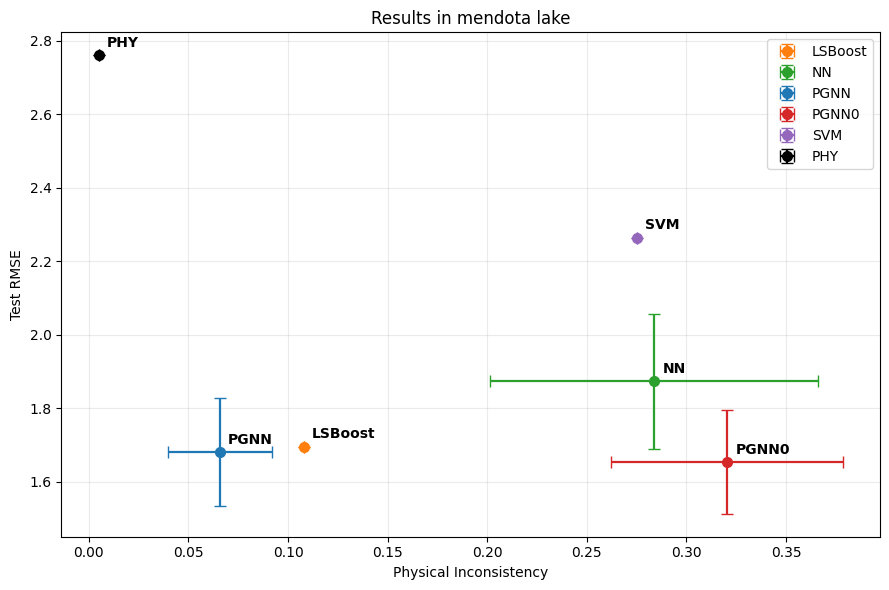

,model,error_mean,error_std,phy_mean,phy_std,n_runs,lake
0,NN,1.874129,0.183839,0.283728,0.082276,50,NaN
1,SVM,2.264574,0.000000,0.275060,0.000000,1,NaN
2,LSBoost,1.695408,0.000000,0.107774,0.000000,1,NaN
3,PGNN0,1.653711,0.140706,0.320394,0.058053,50,NaN
4,PGNN,1.681466,0.147798,0.065799,0.025935,50,NaN
5,PHY,2.760662,0.000000,0.004924,0.000000,1,mendota


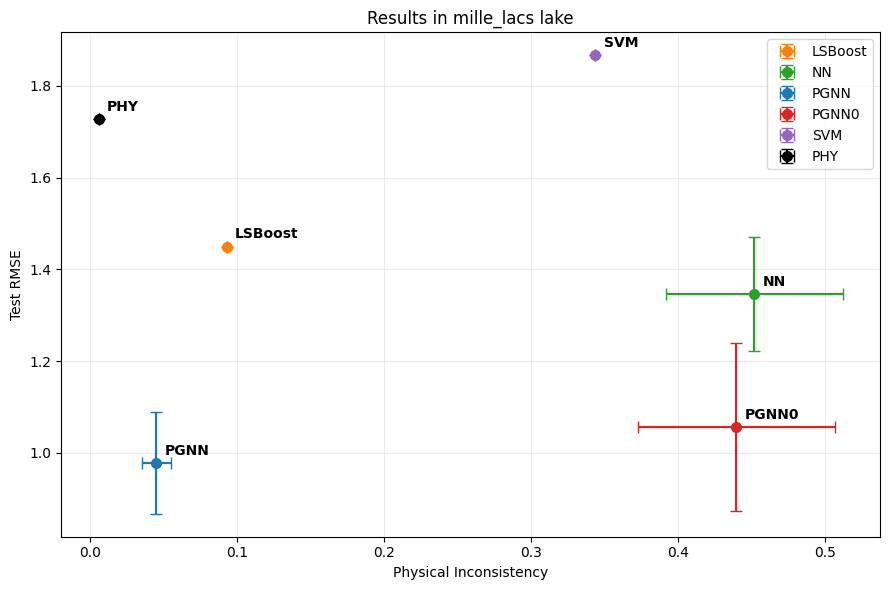

,model,error_mean,error_std,phy_mean,phy_std,n_runs,lake
0,NN,1.345822,0.123904,0.452091,0.060306,50,NaN
1,SVM,1.866649,0.000000,0.344020,0.000000,1,NaN
2,LSBoost,1.449257,0.000000,0.093252,0.000000,1,NaN
3,PGNN0,1.056250,0.183974,0.439856,0.067028,50,NaN
4,PGNN,0.978046,0.110854,0.045363,0.009570,50,NaN
5,PHY,1.727802,0.000000,0.005995,0.000000,1,mille_lacs


In [45]:
plot_df = valid_df.copy()

def density(temp):
    temp = np.asarray(temp, dtype=float)
    return 1000 * (
        1 - (temp + 288.9414) * (temp - 3.9863) ** 2 / (508929.2 * (temp + 68.12963))
    )


def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)
    n = min(y_true.shape[0], y_pred.shape[0])
    if n == 0:
        return np.nan
    return float(np.sqrt(np.mean((y_true[:n] - y_pred[:n]) ** 2)))


def compute_phy_from_datasets(lake_name: str, tr_size: int = 3000):
    sup_path = ROOT / 'datasets' / f'{lake_name}.mat'
    unsup_path = ROOT / 'datasets' / f'{lake_name}_sampled.mat'

    if not sup_path.exists() or not unsup_path.exists():
        return None

    sup = loadmat(sup_path, squeeze_me=True)
    unsup = loadmat(unsup_path, squeeze_me=True)

    # PHY del paper: GLM calibrado. Se prioriza Modeled_temp_tuned.
    y_true = np.asarray(sup.get('Y', sup.get('y')), dtype=float).reshape(-1)
    y_phy = np.asarray(sup.get('Modeled_temp_tuned', sup.get('Modeled_temp')), dtype=float).reshape(-1)

    n_sup = min(y_true.shape[0], y_phy.shape[0])
    if n_sup <= tr_size:
        test_rmse_phy = np.nan
    else:
        test_rmse_phy = rmse(y_true[tr_size:n_sup], y_phy[tr_size:n_sup])

    # Inconsistencia fisica en set no supervisado: fraccion de violaciones de densidad por pares de profundidad consecutivos.
    phy_incon = np.nan
    if 'Modeled_temp_tuned' in unsup:
        temp_unsup = np.asarray(unsup['Modeled_temp_tuned'], dtype=float).reshape(-1)
    elif 'Modeled_temp' in unsup:
        temp_unsup = np.asarray(unsup['Modeled_temp'], dtype=float).reshape(-1)
    else:
        temp_unsup = np.array([], dtype=float)

    date_key = 'datenums' if 'datenums' in unsup else ('udates' if 'udates' in unsup else None)
    if temp_unsup.size > 0 and 'Depth' in unsup and date_key is not None:
        depth = np.asarray(unsup['Depth'], dtype=float).reshape(-1)
        dates = np.asarray(unsup[date_key]).reshape(-1)

        n_unsup = min(temp_unsup.shape[0], depth.shape[0], dates.shape[0])
        temp_unsup = temp_unsup[:n_unsup]
        depth = depth[:n_unsup]
        dates = dates[:n_unsup]

        violations = 0
        total_pairs = 0

        for d in np.unique(dates):
            idx = np.where(dates == d)[0]
            if idx.size < 2:
                continue

            order = idx[np.argsort(depth[idx])]
            rho = density(temp_unsup[order])
            diff = rho[:-1] - rho[1:]
            violations += int(np.sum(diff > 0))
            total_pairs += diff.size

        if total_pairs > 0:
            phy_incon = violations / total_pairs

    return {
        'model': 'PHY',
        'lake': lake_name,
        'error_mean': test_rmse_phy,
        'error_std': 0.0,
        'phy_mean': phy_incon,
        'phy_std': 0.0,
        'n_runs': 1
    }


if plot_df.empty:
    print('No hay datos validos para graficar.')
else:
    model_colors = {
        'NN': '#2ca02c',
        'SVM': '#9467bd',
        'LSBoost': '#ff7f0e',
        # 'LSBoostOriginal': '#8c564b',
        'PGNN0': '#d62728',
        'PGNN': '#1f77b4',
        'PHY': '#000000'
    }

    model_order = ['NN', 'SVM', 'LSBoost', 'PGNN0', 'PGNN', 'PHY']
    # model_order = ['NN', 'SVM', 'LSBoost', 'LSBoostOriginal', 'PGNN0', 'PGNN', 'PHY']
    lakes_to_plot = sorted(plot_df['lake'].dropna().unique())

    for lake_name in lakes_to_plot:
        lake_df = plot_df[plot_df['lake'] == lake_name].copy()
        if lake_df.empty:
            print(f'No hay datos validos para {lake_name}.')
            continue

        model_stats = (
            lake_df
            .groupby('model', as_index=False)
            .agg(
                error_mean=('error', 'mean'),
                error_std=('error', 'std'),
                phy_mean=('physical_inconsistency', 'mean'),
                phy_std=('physical_inconsistency', 'std'),
                n_runs=('model', 'count')
            )
        )

        # Si un modelo tiene una sola corrida, std queda NaN; se reemplaza por 0 para graficar.
        for c in ['error_std', 'phy_std']:
            model_stats[c] = model_stats[c].fillna(0.0)

        # Agrega PHY (GLM calibrado) desde datasets/ con n=3000.
        phy_row = compute_phy_from_datasets(lake_name, tr_size=3000)
        if phy_row is not None:
            model_stats = pd.concat([model_stats, pd.DataFrame([phy_row])], ignore_index=True)

        plt.figure(figsize=(9, 6))

        for _, row in model_stats.iterrows():
            model = row['model']
            x = row['phy_mean']
            y = row['error_mean']
            xerr = row['phy_std']
            yerr = row['error_std']

            plt.errorbar(
                x,
                y,
                xerr=xerr,
                yerr=yerr,
                fmt='o',
                markersize=7,
                capsize=4,
                elinewidth=1.6,
                color=model_colors.get(model, '#7f7f7f'),
                label=model
            )

            plt.annotate(
                model,
                (x, y),
                textcoords='offset points',
                xytext=(6, 6),
                fontsize=10,
                weight='bold'
            )

        plt.xlabel('Physical Inconsistency')
        plt.ylabel('Test RMSE')
        plt.title(f'Results in {lake_name} lake')
        plt.grid(alpha=0.25)
        plt.legend(frameon=True, fontsize=10)
        plt.tight_layout()
        plt.show()

        model_stats['model'] = pd.Categorical(model_stats['model'], categories=model_order, ordered=True)
        display(model_stats.sort_values('model').reset_index(drop=True))

## 4) Figura combinada de ambos lagos (escala fija)

En una sola imagen:
- Izquierda: Mille Lacs
- Derecha: Mendota
- Eje X (PI): 0 a 1
- Eje Y (RMSE): 0.5 a 3

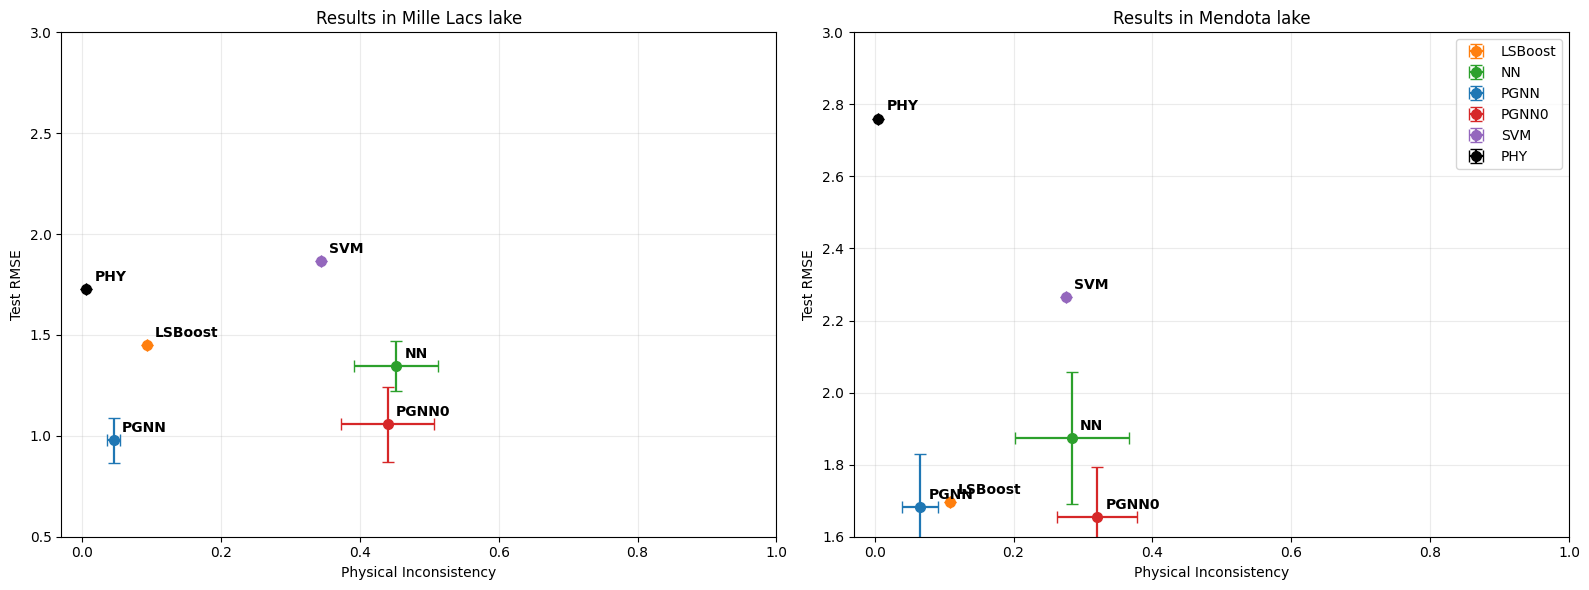

,model,error_mean,error_std,phy_mean,phy_std,n_runs,lake
0,NN,1.874129,0.183839,0.283728,0.082276,50,mendota
1,SVM,2.264574,0.000000,0.275060,0.000000,1,mendota
2,LSBoost,1.695408,0.000000,0.107774,0.000000,1,mendota
3,PGNN0,1.653711,0.140706,0.320394,0.058053,50,mendota
4,PGNN,1.681466,0.147798,0.065799,0.025935,50,mendota
5,PHY,2.760662,0.000000,0.004924,0.000000,1,mendota
6,NN,1.345822,0.123904,0.452091,0.060306,50,mille_lacs
7,SVM,1.866649,0.000000,0.344020,0.000000,1,mille_lacs
8,LSBoost,1.449257,0.000000,0.093252,0.000000,1,mille_lacs
9,PGNN0,1.056250,0.183974,0.439856,0.067028,50,mille_lacs


In [46]:
plot_df = valid_df.copy()

if plot_df.empty:
    print('No hay datos validos para graficar.')
else:
    model_colors = {
        'NN': '#2ca02c',
        'SVM': '#9467bd',
        'LSBoost': '#ff7f0e',
        'PGNN0': '#d62728',
        'PGNN': '#1f77b4',
        'PHY': '#000000'
    }

    model_order = ['NN', 'SVM', 'LSBoost', 'PGNN0', 'PGNN', 'PHY']

    combined_rows = []
    for lake_name in ['mille_lacs', 'mendota']:
        lake_df = plot_df[plot_df['lake'] == lake_name].copy()
        if lake_df.empty:
            continue

        model_stats = (
            lake_df
            .groupby('model', as_index=False)
            .agg(
                error_mean=('error', 'mean'),
                error_std=('error', 'std'),
                phy_mean=('physical_inconsistency', 'mean'),
                phy_std=('physical_inconsistency', 'std'),
                n_runs=('model', 'count')
            )
        )

        for c in ['error_std', 'phy_std']:
            model_stats[c] = model_stats[c].fillna(0.0)

        phy_row = compute_phy_from_datasets(lake_name, tr_size=3000)
        if phy_row is not None:
            model_stats = pd.concat([model_stats, pd.DataFrame([phy_row])], ignore_index=True)

        model_stats['lake'] = lake_name
        combined_rows.append(model_stats)

    if not combined_rows:
        print('No hay datos para figura combinada.')
    else:
        combined_stats = pd.concat(combined_rows, ignore_index=True)

        fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=False)
        lake_panels = [('mille_lacs', 'Mille Lacs'), ('mendota', 'Mendota')]

        for ax, (lake_name, lake_title) in zip(axes, lake_panels):
            lake_stats = combined_stats[combined_stats['lake'] == lake_name].copy()
            if lake_stats.empty:
                ax.set_title(f'{lake_title} (sin datos)')
                ax.set_xlim(-0.03, 1)
                if lake_name == 'mendota':
                    ax.set_ylim(1.6, 3.0)
                else:
                    ax.set_ylim(0.5, 3.0)
                ax.grid(alpha=0.25)
                continue

            for _, row in lake_stats.iterrows():
                model = row['model']
                x = row['phy_mean']
                y = row['error_mean']
                xerr = row['phy_std']
                yerr = row['error_std']

                ax.errorbar(
                    x, y,
                    xerr=xerr, yerr=yerr,
                    fmt='o', markersize=7, capsize=4, elinewidth=1.6,
                    color=model_colors.get(model, '#7f7f7f'),
                    label=model
                )
                ax.annotate(
                    model,
                    (x, y),
                    textcoords='offset points',
                    xytext=(6, 6),
                    fontsize=10,
                    weight='bold'
                )

            ax.set_title(f'Results in {lake_title} lake')
            ax.set_xlim(-0.03, 1)
            if lake_name == 'mendota':
                ax.set_ylim(1.6, 3.0)
            else:
                ax.set_ylim(0.5, 3.0)
            ax.set_xlabel('Physical Inconsistency')
            ax.grid(alpha=0.25)

        axes[0].set_ylabel('Test RMSE')
        axes[1].set_ylabel('Test RMSE')

        handles, labels = axes[1].get_legend_handles_labels()
        uniq = dict(zip(labels, handles))
        axes[1].legend(uniq.values(), uniq.keys(), frameon=True, fontsize=10, loc='best')

        plt.tight_layout()
        plt.show()

        combined_stats['model'] = pd.Categorical(combined_stats['model'], categories=model_order, ordered=True)
        display(combined_stats.sort_values(['lake', 'model']).reset_index(drop=True))